# PENTAKSIRAN BERTERUSAN AMALI 1: SIMULASI DEPLOYMENT MODEL CNN ASAS

### 1. MAKLUMAT CALON
* **Nama Calon:** [Muhammad Haikal bin Zakaria]
* **Angka Giliran:** [PKV0125KA006]
* **Kod/Kursus:** DKA3223 AI Untuk Computer Vision

---

### 2. PERNYATAAN HAK CIPTA DATASET
Hak cipta dataset imej adalah terpelihara dan dibekalkan khas untuk tujuan pentaksiran akademik Kolej Vokasional Balik Pulau sahaja. Penggunaan atau pengedaran semula tanpa kebenaran adalah dilarang.

---

### 3. ETIKA PEMBANGUNAN AI
* **Integriti Data:** Memastikan tiada sebarang pemalsuan atau manipulasi terhadap imej ujian dan output hasil keputusan inferens.
* **Kebolehulangan (Reproducibility):** Menetapkan nilai random seed standard (42) bagi menjamin kebolehulangan hasil keputusan inferens.
* **Tanggungjawab Privasi:** Pengurusan imej dilakukan mengikut piawaian etika dan privasi data visual industri.

Mounted at /content/drive
Train folder exists: True
Test folder exists : True
Train classes: ['dogs', 'cats']
Test classes : ['cats', 'dogs']
Peranti digunakan: cuda
Nama peranti GPU: Tesla T4
[SEDIA] Image transforms telah ditetapkan.
Class names     : ['cats', 'dogs']
Class mapping   : {'cats': 0, 'dogs': 1}
Training images : 120
Testing images  : 99
Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])


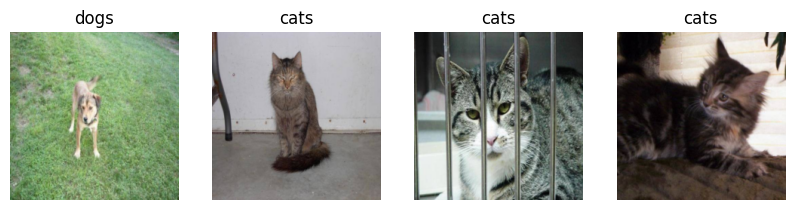

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Epoch 1/3: Loss=5.6618, Accuracy=0.4750
Epoch 2/3: Loss=5.5830, Accuracy=0.5000
Epoch 3/3: Loss=5.5525, Accuracy=0.5000


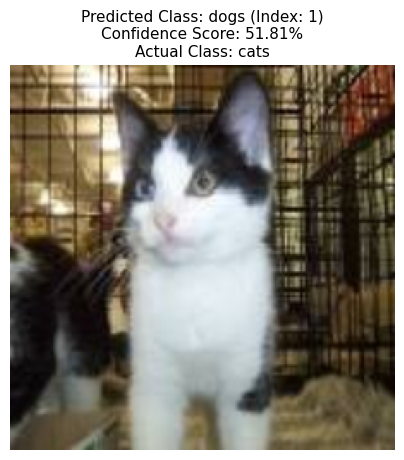

Indeks Ramalan   : 1
Nama Kelas       : dogs
Nilai Keyakinan  : 51.81%
Model disimpan sebagai: /content/drive/MyDrive/Colab Notebooks/kvtron_catdog_cnn_model.pth


In [1]:
# ==============================================================================
# PENTAKSIRAN BERTERUSAN AMALI 1: KV-TRON CNN VISION TRAINING
# KURSUS: DKA3223 - ARTIFICIAL INTELLIGENCE FOR COMPUTER VISION
# ==============================================================================

# LANGKAH 1: Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# LANGKAH 2: Tetapkan Laluan Dataset
dataset_path = "/content/drive/MyDrive/KVTRON_CNN_Dataset/data_dogcat"

# Semakan automatik jika laluan utama tiada
if not os.path.exists(dataset_path):
    print(f"[AMARAN] Laluan {dataset_path} tiada. Mencari folder 'data_dogcat'...")
    for root, dirs, _ in os.walk("/content/drive/MyDrive"):
        if "data_dogcat" in dirs:
            dataset_path = os.path.join(root, "data_dogcat")
            print(f"[JUMPA] Laluan baharu ditemui: {dataset_path}")
            break

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists :", os.path.exists(test_dir))

if os.path.exists(train_dir): print("Train classes:", os.listdir(train_dir))
if os.path.exists(test_dir): print("Test classes :", os.listdir(test_dir))

# Import Pustaka PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 5.1 (c) Semakan Konfigurasi & Kebolehulangan
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Peranti digunakan:", device)
if torch.cuda.is_available():
    print("Nama peranti GPU:", torch.cuda.get_device_name(0))

# LANGKAH 3: Konfigurasi Transformasi Imej (224x224 & Tensor)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
print("[SEDIA] Image transforms telah ditetapkan.")

# LANGKAH 4: Memuatkan Dataset Menggunakan ImageFolder
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    print("[RALAT CRITICAL] Folder 'train' atau 'test' tidak dijumpai. Sila pastikan dataset telah di-upload.")
    train_dataset = test_dataset = None
else:
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    print("Class names     :", train_dataset.classes)
    print("Class mapping   :", train_dataset.class_to_idx)
    print("Training images :", len(train_dataset))
    print("Testing images  :", len(test_dataset))

# LANGKAH 5: Membina DataLoader & Visualisasi Sampel
if train_dataset is None or test_dataset is None:
    print("[BELUM SEDIA] Load dataset dahulu.")
    train_loader = test_loader = None
else:
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    images, labels = next(iter(train_loader))
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

    plt.figure(figsize=(10,4))
    for i in range(min(4, len(images))):
        image = images[i].permute(1,2,0)
        class_name = train_dataset.classes[labels[i].item()]
        plt.subplot(1,4,i+1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

# LANGKAH 6: Pembinaan Model CNN
INPUT_CHANNELS = 3   # RGB
OUTPUT_CLASSES = 2   # Cat & Dog

class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, OUTPUT_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

try:
    model = CatDogCNN().to(device)
    print(model)
except Exception as e:
    model = None
    print("[BELUM LENGKAP]", e)

# LANGKAH 7: Tetapan Hyperparameters
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    epochs = 3

# LANGKAH 8: Gelung Latihan (Training Loop)
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
else:
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total if total else 0
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss:.4f}, Accuracy={accuracy:.4f}")

    training_complete = True

# LANGKAH 9: Penilaian Model dan Inferens
# ==============================================================================
# LANGKAH 9: Inferens Masa Nyata Beserta Confidence Score (%) (DIBAIKI)
# ==============================================================================
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    # 1. Tukar model ke mod penilaian
    model.eval()

    # 2. Ambil imej pertama dari dataset ujian
    image, actual_label = test_dataset[0]
    input_tensor = image.unsqueeze(0).to(device)

    # 3. Jalankan inferens tanpa kira gradien (torch.no_grad)
    with torch.no_grad():
        output = model(input_tensor)

        # Tukar output logit kepada nilai kebarangkalian peratusan (%) guna Softmax
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_label = torch.max(probabilities, dim=1)

        predicted_idx = predicted_label.item()
        confidence_pct = confidence.item() * 100  # Kira peratusan %

    predicted_class = test_dataset.classes[predicted_idx]
    actual_class = test_dataset.classes[actual_label]

    # 4. Paparkan Visual Imej + Tajuk Mengandungi Confidence Score (%)
    plt.figure(figsize=(5, 5))
    plt.imshow(image.permute(1, 2, 0))
    plt.title(
        f"Predicted Class: {predicted_class} (Index: {predicted_idx})\n"
        f"Confidence Score: {confidence_pct:.2f}%\n"
        f"Actual Class: {actual_class}",
        fontsize=11
    )
    plt.axis("off")
    plt.show()

    # Cetak teks output
    print(f"Indeks Ramalan   : {predicted_idx}")
    print(f"Nama Kelas       : {predicted_class}")
    print(f"Nilai Keyakinan  : {confidence_pct:.2f}%")

# LANGKAH 10: Menyimpan Model
save_dir = "/content/drive/MyDrive/Colab Notebooks"
save_path = os.path.join(save_dir, "kvtron_catdog_cnn_model.pth")

if globals().get("training_complete", False):
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print("Model disimpan sebagai:", save_path)
else:
    print("Model belum disimpan kerana training_complete masih False.")